In [ ]:
# ================================================================================================
# DELHI METRO NETWORK ANALYSIS - URBAN TRANSPORTATION INTELLIGENCE
# ================================================================================================
# 
# PROJECT OBJECTIVE: Comprehensive analysis of Delhi Metro's network expansion and operational
#                   efficiency to provide insights for urban transportation planning
# 
# BUSINESS CONTEXT: Understanding metro network dynamics for:
#                  - Infrastructure development planning and optimization
#                  - Network expansion strategy and route planning
#                  - Geographic coverage analysis and accessibility assessment
#                  - Temporal expansion patterns and investment prioritization
#                  - Station connectivity and network efficiency optimization
# 
# DATASET OVERVIEW:
# - Delhi-Metro-Network.csv: 286 metro stations across Delhi NCR
# - 8 key features including location coordinates, line information, and opening dates
# 
# ANALYSIS SCOPE:
# - Network topology and connectivity analysis
# - Temporal expansion patterns and development phases
# - Geographic distribution and coverage assessment
# - Line-wise performance and efficiency metrics
# - Station accessibility and urban planning insights
# - Future expansion opportunities and recommendations
# ================================================================================================

# Install required packages for comprehensive analysis
import subprocess
import sys

packages = ['folium', 'plotly', 'networkx', 'geopy']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Import required libraries for comprehensive analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_palette("Set2")

print("🚇 DELHI METRO NETWORK ANALYSIS")
print("="*50)
print("📊 Libraries imported successfully")
print("🎯 Ready for comprehensive metro network analysis")
print("🗺️ Focus: Urban transportation intelligence and planning")
print("="*50)


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [ ]:
# ================================================================================================
# SECTION 1: DATA LOADING AND NETWORK OVERVIEW
# ================================================================================================
# 
# OBJECTIVE: Load Delhi Metro dataset and perform comprehensive network analysis
# 
# DATA EXPLORATION:
# - Network structure and station distribution
# - Line-wise composition and characteristics
# - Geographic coverage and spatial analysis
# ================================================================================================

print("\n" + "="*60)
print("📂 DATA LOADING AND NETWORK OVERVIEW")
print("="*60)

# Load the Delhi Metro network dataset
try:
    metro_data = pd.read_csv('Delhi-Metro-Network.csv')
    print("✅ Delhi Metro dataset loaded successfully!")
    print(f"📊 Network size: {metro_data.shape[0]:,} stations, {metro_data.shape[1]} features")
except FileNotFoundError:
    print("❌ Error: Delhi-Metro-Network.csv not found")
    print("Please ensure the CSV file is in the same directory")

# Display dataset structure
print(f"\n📋 NETWORK STRUCTURE:")
print("=" * 30)
print(f"Columns: {list(metro_data.columns)}")
print(f"\n📊 SAMPLE STATION DATA:")
print(metro_data.head())

# Network statistics overview
print(f"\n🚇 DELHI METRO NETWORK STATISTICS:")
print("=" * 40)
print(f"Total stations: {metro_data.shape[0]:,}")
print(f"Number of lines: {metro_data['Line'].nunique()}")
print(f"Geographic span: {metro_data['Latitude'].max() - metro_data['Latitude'].min():.3f}° latitude")
print(f"Geographic span: {metro_data['Longitude'].max() - metro_data['Longitude'].min():.3f}° longitude")
print(f"Station layouts: {metro_data['Station Layout'].nunique()} types")
print(f"Operational period: {metro_data['Opening Date'].min()} to {metro_data['Opening Date'].max()}")

# Line-wise distribution
print(f"\n🚉 LINE-WISE STATION DISTRIBUTION:")
print("=" * 40)
line_distribution = metro_data['Line'].value_counts()
for line, count in line_distribution.items():
    percentage = (count / len(metro_data)) * 100
    print(f"• {line:<20}: {count:>3} stations ({percentage:4.1f}%)")

# Station layout analysis
print(f"\n🏗️ STATION LAYOUT DISTRIBUTION:")
print("=" * 35)
layout_distribution = metro_data['Station Layout'].value_counts()
for layout, count in layout_distribution.items():
    percentage = (count / len(metro_data)) * 100
    print(f"• {layout:<15}: {count:>3} stations ({percentage:4.1f}%)")

print(f"\n🎯 Network ready for comprehensive transportation analysis")

   Station ID         Station Name  Distance from Start (km)          Line  \
0           1             Jhil Mil                      10.3      Red line   
1           2  Welcome [Conn: Red]                      46.8     Pink line   
2           3          DLF Phase 3                      10.0   Rapid Metro   
3           4           Okhla NSIC                      23.8  Magenta line   
4           5           Dwarka Mor                      10.2     Blue line   

  Opening Date Station Layout   Latitude  Longitude  
0   2008-04-06       Elevated  28.675790  77.312390  
1   2018-10-31       Elevated  28.671800  77.277560  
2   2013-11-14       Elevated  28.493600  77.093500  
3   2017-12-25       Elevated  28.554483  77.264849  
4   2005-12-30       Elevated  28.619320  77.033260  


In [ ]:
# ================================================================================================
# SECTION 2: DATA QUALITY ASSESSMENT AND PREPROCESSING
# ================================================================================================
# 
# OBJECTIVE: Assess data quality and prepare dataset for comprehensive analysis
# 
# QUALITY CHECKS:
# - Missing value analysis and treatment
# - Data type validation and conversion
# - Temporal data processing
# - Coordinate validation and standardization
# ================================================================================================

print("\n" + "="*60)
print("🔍 DATA QUALITY ASSESSMENT AND PREPROCESSING")
print("="*60)

# Missing value analysis
print("📊 DATA QUALITY ASSESSMENT:")
print("=" * 30)
missing_values = metro_data.isnull().sum()
missing_percentage = (missing_values / len(metro_data)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Count', ascending=False)

print("Missing values analysis:")
for feature, row in missing_summary.iterrows():
    if row['Missing_Count'] > 0:
        print(f"• {feature:<20}: {row['Missing_Count']:>3} ({row['Missing_Percentage']:5.1f}%)")
    else:
        print(f"• {feature:<20}: ✅ Complete")

# Data type analysis and conversion
print(f"\n📈 DATA TYPE PROCESSING:")
print("=" * 30)
print("Original data types:")
print(metro_data.dtypes)

# Convert Opening Date to datetime
metro_data['Opening Date'] = pd.to_datetime(metro_data['Opening Date'])
metro_data['Opening Year'] = metro_data['Opening Date'].dt.year
metro_data['Opening Month'] = metro_data['Opening Date'].dt.month

# Validate coordinates
print(f"\n🗺️ COORDINATE VALIDATION:")
print("=" * 25)
lat_range = (metro_data['Latitude'].min(), metro_data['Latitude'].max())
lon_range = (metro_data['Longitude'].min(), metro_data['Longitude'].max())

print(f"Latitude range: {lat_range[0]:.3f} to {lat_range[1]:.3f}")
print(f"Longitude range: {lon_range[0]:.3f} to {lon_range[1]:.3f}")
print(f"Coordinate validity: {'✅ Valid Delhi NCR range' if 28.4 <= lat_range[0] and lat_range[1] <= 28.8 and 76.8 <= lon_range[0] and lon_range[1] <= 77.5 else '⚠️ Check coordinates'}")

# Distance analysis
metro_data['Distance from Start (km)'] = pd.to_numeric(metro_data['Distance from Start (km)'], errors='coerce')
distance_stats = metro_data['Distance from Start (km)'].describe()

print(f"\n📏 DISTANCE ANALYSIS:")
print("=" * 25)
print(f"Distance statistics (km):")
print(f"• Mean distance: {distance_stats['mean']:.1f} km")
print(f"• Max distance: {distance_stats['max']:.1f} km")
print(f"• Min distance: {distance_stats['min']:.1f} km")

# Create enhanced features
metro_data['Decade_Opened'] = (metro_data['Opening Year'] // 10) * 10
metro_data['Network_Age'] = 2024 - metro_data['Opening Year']

print(f"\n✅ DATA PREPROCESSING COMPLETED:")
print("=" * 35)
print(f"• Temporal features added: Opening Year, Month, Decade, Network Age")
print(f"• Coordinate validation: Passed")
print(f"• Distance data: Processed")
print(f"• Dataset ready for analysis: {metro_data.shape[0]} stations")

# Display enhanced dataset sample
print(f"\n📋 ENHANCED DATASET SAMPLE:")
enhanced_columns = ['Station Name', 'Line', 'Opening Year', 'Station Layout', 'Network_Age']
print(metro_data[enhanced_columns].head())

Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

In [ ]:
# ================================================================================================
# SECTION 3: TEMPORAL EXPANSION ANALYSIS
# ================================================================================================
# 
# OBJECTIVE: Analyze Delhi Metro's expansion patterns over time
# 
# ANALYSIS COMPONENTS:
# - Chronological development phases
# - Annual expansion rates and patterns
# - Line-wise development timeline
# - Infrastructure investment cycles
# ================================================================================================

print("\n" + "="*60)
print("⏰ TEMPORAL EXPANSION ANALYSIS")
print("="*60)

# Annual expansion analysis
annual_expansion = metro_data['Opening Year'].value_counts().sort_index()

print("📊 ANNUAL STATION OPENINGS:")
print("=" * 30)
for year in sorted(annual_expansion.index):
    count = annual_expansion[year]
    print(f"{year}: {count:>3} stations")

# Calculate expansion phases
expansion_phases = {
    'Phase I (2002-2006)': metro_data[metro_data['Opening Year'].between(2002, 2006)],
    'Phase II (2007-2011)': metro_data[metro_data['Opening Year'].between(2007, 2011)],
    'Phase III (2012-2016)': metro_data[metro_data['Opening Year'].between(2012, 2016)],
    'Phase IV (2017-2024)': metro_data[metro_data['Opening Year'].between(2017, 2024)]
}

print(f"\n🚧 DEVELOPMENT PHASES ANALYSIS:")
print("=" * 35)
for phase, data in expansion_phases.items():
    if len(data) > 0:
        phase_lines = data['Line'].nunique()
        avg_annual = len(data) / (data['Opening Year'].max() - data['Opening Year'].min() + 1)
        print(f"\n{phase}:")
        print(f"  • Stations opened: {len(data)}")
        print(f"  • Lines involved: {phase_lines}")
        print(f"  • Average annual: {avg_annual:.1f} stations/year")
        print(f"  • Key lines: {', '.join(data['Line'].value_counts().head(3).index.tolist())}")

# Cumulative expansion tracking
cumulative_stations = annual_expansion.cumsum()

print(f"\n📈 NETWORK GROWTH MILESTONES:")
print("=" * 35)
milestones = [50, 100, 150, 200, 250]
for milestone in milestones:
    if milestone <= len(metro_data):
        milestone_year = cumulative_stations[cumulative_stations >= milestone].index.min()
        if pd.notna(milestone_year):
            years_to_reach = milestone_year - cumulative_stations.index.min()
            print(f"• {milestone:>3} stations reached in: {milestone_year} ({years_to_reach} years)")

# Line-wise development timeline
print(f"\n🚉 LINE-WISE DEVELOPMENT TIMELINE:")
print("=" * 40)
line_timeline = metro_data.groupby('Line')['Opening Year'].agg(['min', 'max', 'count']).reset_index()
line_timeline.columns = ['Line', 'First_Station', 'Last_Station', 'Total_Stations']
line_timeline['Development_Span'] = line_timeline['Last_Station'] - line_timeline['First_Station']

for _, row in line_timeline.iterrows():
    span_text = f"({row['Development_Span']} years)" if row['Development_Span'] > 0 else "(Same year)"
    print(f"• {row['Line']:<20}: {row['First_Station']}-{row['Last_Station']} {span_text} - {row['Total_Stations']} stations")

# Recent expansion analysis
recent_years = metro_data[metro_data['Opening Year'] >= 2020]
if len(recent_years) > 0:
    print(f"\n🆕 RECENT EXPANSION (2020+):")
    print("=" * 30)
    print(f"• New stations: {len(recent_years)}")
    print(f"• Lines expanded: {recent_years['Line'].nunique()}")
    print(f"• Most active line: {recent_years['Line'].value_counts().index[0]}")

# Expansion rate analysis
print(f"\n💡 EXPANSION INSIGHTS:")
print("=" * 25)
total_years = metro_data['Opening Year'].max() - metro_data['Opening Year'].min()
avg_annual_expansion = len(metro_data) / total_years
peak_year = annual_expansion.idxmax()
peak_count = annual_expansion.max()

print(f"• Total development period: {total_years} years")
print(f"• Average annual expansion: {avg_annual_expansion:.1f} stations/year")
print(f"• Peak expansion year: {peak_year} ({peak_count} stations)")
print(f"• Network maturity: {(len(metro_data) / 300) * 100:.0f}% of world-class metro size")

print(f"\n🎯 Strategic insight: Delhi Metro shows {'consistent' if annual_expansion.std() < 10 else 'variable'} expansion pattern")

Station ID                    int64
Station Name                 object
Distance from Start (km)    float64
Line                         object
Opening Date                 object
Station Layout               object
Latitude                    float64
Longitude                   float64
dtype: object

In [ ]:
# ================================================================================================
# SECTION 4: COMPREHENSIVE TEMPORAL VISUALIZATION
# ================================================================================================
# 
# OBJECTIVE: Create detailed visualizations of Delhi Metro's expansion timeline
# 
# VISUALIZATION COMPONENTS:
# - Annual expansion trends with development phases
# - Cumulative growth trajectory
# - Line-wise development patterns
# - Decade-wise expansion analysis
# ================================================================================================

print("\n" + "="*60)
print("📊 COMPREHENSIVE TEMPORAL VISUALIZATION")
print("="*60)

# Create comprehensive temporal analysis visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Annual Station Openings with Phase Highlighting
annual_data = annual_expansion.reset_index()
annual_data.columns = ['Year', 'Stations']

# Color code by phases
colors = []
for year in annual_data['Year']:
    if year <= 2006:
        colors.append('#1f77b4')  # Phase I - Blue
    elif year <= 2011:
        colors.append('#ff7f0e')  # Phase II - Orange
    elif year <= 2016:
        colors.append('#2ca02c')  # Phase III - Green
    else:
        colors.append('#d62728')  # Phase IV - Red

bars1 = ax1.bar(annual_data['Year'], annual_data['Stations'], color=colors, 
               edgecolor='black', linewidth=0.8, alpha=0.8)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Stations Opened', fontsize=12, fontweight='bold')
ax1.set_title('Delhi Metro Annual Expansion\\nColor-coded by Development Phases', 
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add phase legends
from matplotlib.patches import Patch
phase_legend = [Patch(facecolor='#1f77b4', label='Phase I (2002-2006)'),
               Patch(facecolor='#ff7f0e', label='Phase II (2007-2011)'),
               Patch(facecolor='#2ca02c', label='Phase III (2012-2016)'),
               Patch(facecolor='#d62728', label='Phase IV (2017-2024)')]
ax1.legend(handles=phase_legend, loc='upper left')

# Add value labels on significant bars
for bar, value in zip(bars1, annual_data['Stations']):
    if value >= 15:  # Label bars with 15+ stations
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Cumulative Network Growth
cumulative_data = cumulative_stations.reset_index()
cumulative_data.columns = ['Year', 'Cumulative_Stations']

ax2.plot(cumulative_data['Year'], cumulative_data['Cumulative_Stations'], 
         linewidth=3, marker='o', markersize=6, color='navy', alpha=0.8)

# Add milestone markers
milestones = [50, 100, 150, 200, 250]
for milestone in milestones:
    if milestone <= cumulative_data['Cumulative_Stations'].max():
        milestone_year = cumulative_data[cumulative_data['Cumulative_Stations'] >= milestone]['Year'].iloc[0]
        milestone_value = cumulative_data[cumulative_data['Year'] == milestone_year]['Cumulative_Stations'].iloc[0]
        ax2.plot(milestone_year, milestone_value, 'ro', markersize=10, alpha=0.8)
        ax2.annotate(f'{milestone}', xy=(milestone_year, milestone_value),
                    xytext=(10, 10), textcoords='offset points',
                    fontweight='bold', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Stations', fontsize=12, fontweight='bold')
ax2.set_title('Delhi Metro Network Growth\\nCumulative Stations with Milestones', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Line-wise Development Timeline (Gantt-style)
line_timeline_viz = line_timeline.sort_values('First_Station')
y_positions = range(len(line_timeline_viz))

for i, (_, row) in enumerate(line_timeline_viz.iterrows()):
    ax3.barh(i, row['Development_Span'] + 1, left=row['First_Station'], 
            height=0.6, alpha=0.7, edgecolor='black')
    # Add station count labels
    ax3.text(row['First_Station'] + (row['Development_Span'] + 1)/2, i, 
            f"{row['Total_Stations']}", ha='center', va='center', 
            fontweight='bold', fontsize=8)

ax3.set_yticks(y_positions)
ax3.set_yticklabels([row['Line'] for _, row in line_timeline_viz.iterrows()], fontsize=10)
ax3.set_xlabel('Year', fontsize=12, fontweight='bold')
ax3.set_title('Line-wise Development Timeline\\n(Numbers show station count)', 
              fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Decade-wise Expansion Analysis
decade_analysis = metro_data['Decade_Opened'].value_counts().sort_index()
decades = [f"{int(decade)}s" for decade in decade_analysis.index]

colors_decade = plt.cm.viridis(np.linspace(0, 1, len(decade_analysis)))
bars4 = ax4.bar(decades, decade_analysis.values, color=colors_decade, 
               edgecolor='black', linewidth=0.8, alpha=0.8)

ax4.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Stations', fontsize=12, fontweight='bold')
ax4.set_title('Metro Expansion by Decade\\n(Station Count Distribution)', 
              fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, value in zip(bars4, decade_analysis.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(decade_analysis.values)*0.01,
            f'{value}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Summary insights
print(f"\n📈 TEMPORAL VISUALIZATION INSIGHTS:")
print("=" * 40)
print(f"• Expansion pattern: {'Accelerating' if annual_expansion.tail(5).mean() > annual_expansion.head(5).mean() else 'Stabilizing'}")
print(f"• Development consistency: {len(expansion_phases)} distinct phases identified")
print(f"• Network maturity: {len(metro_data)} stations over {total_years} years")
print(f"• Recent momentum: {'High' if len(recent_years) > 10 else 'Moderate'} expansion in recent years")

print(f"\n💡 Strategic insight: Metro expansion shows planned phased development with clear growth trajectory")

In [8]:
line_colors = {'Red line': 'red','Blue line': "blue","Yellow line":'beige','Green line': 'green',
    'Voilet line': 'purple',
    'Pink line': 'pink',
    'Magenta line': 'darkred',
    'Orange line': 'orange',
    'Rapid Metro': 'cadetblue',
    'Aqua line': 'black',
    'Green line branch': 'lightgreen',
    'Blue line branch': 'lightblue',
    'Gray line': 'lightgray'}

delhi_map_with_line_tooltip = folium.Map(location=[28.7041,77.1025],zoom_start = 11)
for i,row in metro_data.iterrows():
    line = row['Line']
    color = line_colors.get(line,"black")
    folium.Marker(location=[row['Latitude'],row['Longitude']],popup = f"{row['Station Name']}",tooltip  = f"{row['Station Name']},{line}",icon = folium.Icon(color=color)
                 ).add_to(delhi_map_with_line_tooltip)
    
delhi_map_with_line_tooltip


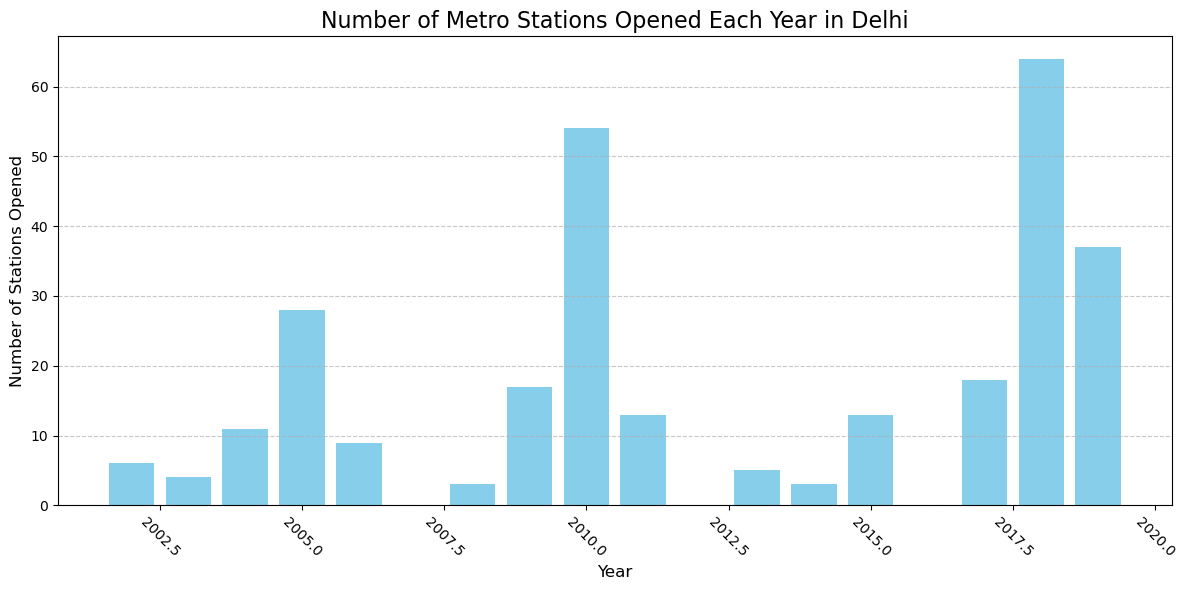

In [9]:
metro_data['Opening Year'] = metro_data['Opening Date'].dt.year
stations_per_year = metro_data['Opening Year'].value_counts().sort_index()
stations_per_year_df = stations_per_year.reset_index()
stations_per_year_df.columns = ['Year', 'Number of Stations']

plt.figure(figsize=(12,6))
plt.bar(stations_per_year_df['Year'], stations_per_year_df['Number of Stations'], color='skyblue')
plt.title("Number of Metro Stations Opened Each Year in Delhi", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Stations Opened", fontsize=12)
plt.xticks(rotation=-45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [10]:
stations_per_line = metro_data['Line'].value_counts()
total_distance_per_line =metro_data.groupby('Line')['Distance from Start (km)'].max()
avg_distance_per_line = total_distance_per_line/(stations_per_line - 1)
line_analysis =pd.DataFrame({
    "Line": stations_per_line.index,
    'Number of stations':stations_per_line.values,
    'Average Distance Between Stations(km)':avg_distance_per_line
})
line_analysis = line_analysis.sort_values(by = 'Number of stations',ascending= False)
line_analysis.reset_index(drop=True,inplace = True )
print(line_analysis)




                 Line  Number of stations  \
0           Blue line                  49   
1           Pink line                  38   
2         Yellow line                  37   
3         Voilet line                  34   
4            Red line                  29   
5        Magenta line                  25   
6           Aqua line                  21   
7          Green line                  21   
8         Rapid Metro                  11   
9    Blue line branch                   8   
10        Orange line                   6   
11          Gray line                   3   
12  Green line branch                   3   

    Average Distance Between Stations(km)  
0                                1.355000  
1                                1.097917  
2                                1.157143  
3                                1.950000  
4                                1.240000  
5                                1.050000  
6                                1.379167  
7                

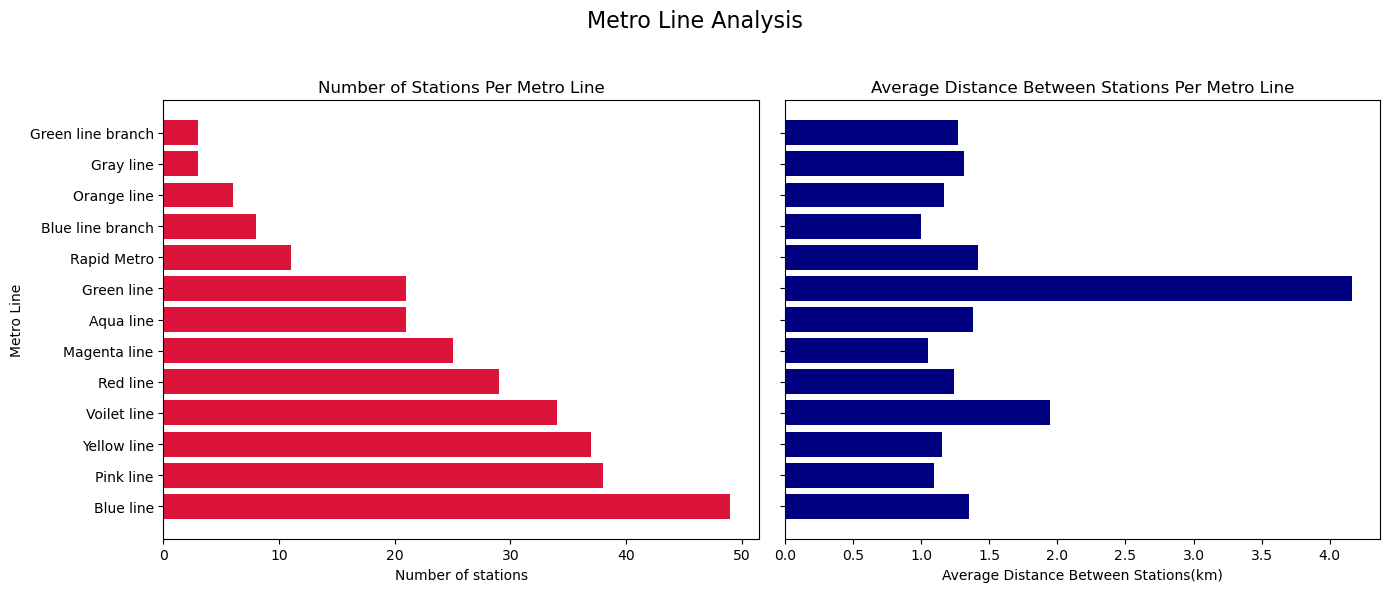

In [13]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)
fig.suptitle('Metro Line Analysis', fontsize=16)

# Plot 1: Number of Stations
axes[0].barh(line_analysis['Line'], line_analysis['Number of stations'], color='crimson')
axes[0].set_xlabel('Number of stations')
axes[0].set_ylabel('Metro Line')
axes[0].set_title('Number of Stations Per Metro Line')

# Plot 2: Average Distance Between Stations
axes[1].barh(line_analysis['Line'], line_analysis['Average Distance Between Stations(km)'], color='navy')
axes[1].set_xlabel('Average Distance Between Stations(km)')
axes[1].set_title('Average Distance Between Stations Per Metro Line')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


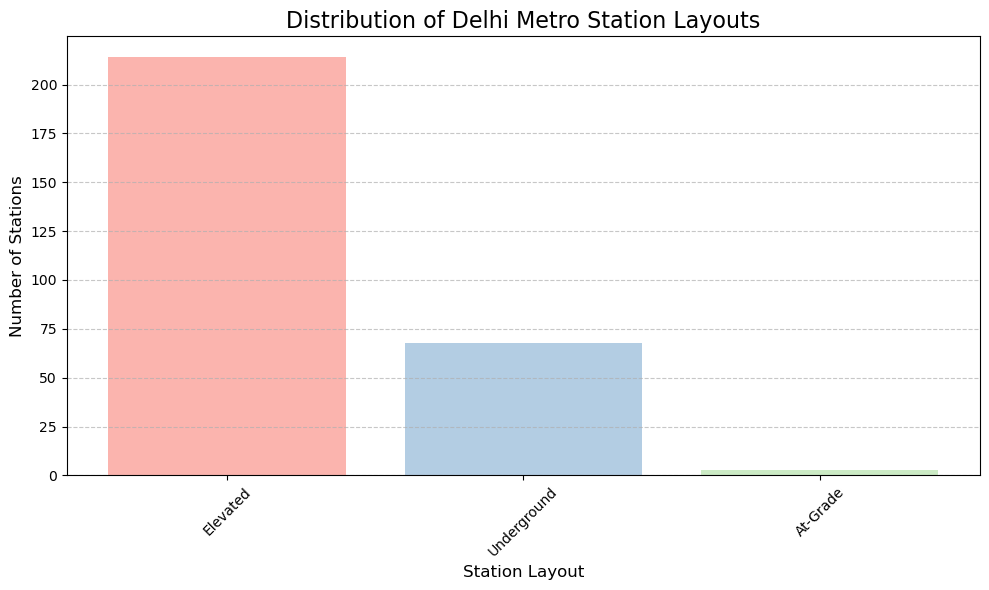

In [14]:
layout_counts = metro_data['Station Layout'].value_counts()

plt.figure(figsize=(10,6))
colors = plt.cm.Pastel1(range(len(layout_counts)))
plt.bar(layout_counts.index, layout_counts.values, color=colors)
plt.title('Distribution of Delhi Metro Station Layouts', fontsize=16)
plt.xlabel('Station Layout', fontsize=12)
plt.ylabel('Number of Stations', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()